# Numerical Heston — Initial exploration
**Goal.** Build the numerical (simulation-based) Heston pipeline in numpy, grounded in real market data.
The eventual target is a generative model over implied-volatility surfaces; this notebook builds the
foundations in order:

1. **Market IV surface** from the NSE F&O data — the object Heston is calibrated to (this notebook).
2. **Numerical Heston simulator** (full-truncation Euler Monte-Carlo) → model IV surface *(next cells)*.
3. **Calibration** of $(\kappa,\theta,\xi,\rho,v_0)$ to the market surface *(later)*.
4. **Synthetic surface dataset** by sampling parameters around the calibrated values — the flow-matching target *(later)*.

> The uploaded CSV is **real market option prices** (NSE F&O end-of-day bhavcopy), not Heston output.
> It plays the role of the *calibration target / reality anchor*, not the training data itself.

## 0. Data exploration

NSE F&O end-of-day bhavcopy. We profile it before using it: which instruments, date range, and how
liquid the NIFTY option chain actually is (this drives every downstream choice).

In [2]:
import numpy as np
import pandas as pd
from scipy.stats import norm
from scipy.optimize import brentq
import matplotlib.pyplot as plt

CSV = "data/3mfanddo.csv"   # adjust path if needed

cols = ["INSTRUMENT","SYMBOL","EXPIRY_DT","STRIKE_PR","OPTION_TYP","CLOSE","CONTRACTS","OPEN_INT","TIMESTAMP"]
df = pd.read_csv(CSV, usecols=cols)
print("rows:", len(df))
print("\ninstruments:\n", df.INSTRUMENT.value_counts())
df["TS"] = pd.to_datetime(df.TIMESTAMP, format="%d-%b-%Y", errors="coerce")
print("\ntrade dates:", df.TS.min().date(), "->", df.TS.max().date(), "|", df.TS.nunique(), "days")
print("\ntop symbols:\n", df.SYMBOL.value_counts().head(6))

rows: 2533210

instruments:
 INSTRUMENT
OPTSTK    2152486
OPTIDX     348752
FUTSTK      31351
FUTIDX        621
Name: count, dtype: int64

trade dates: 2019-08-01 -> 2019-11-15 | 69 days

top symbols:
 SYMBOL
NIFTY        229069
BANKNIFTY     83707
NIFTYIT       36597
COLPAL        20391
NBCC          19287
NCC           18587
Name: count, dtype: int64


In [3]:
# NIFTY index options are the clean instrument for Heston.
opt = df[(df.SYMBOL=="NIFTY") & (df.INSTRUMENT=="OPTIDX")].copy()
opt["EXP"] = pd.to_datetime(opt.EXPIRY_DT, format="%d-%b-%Y")
print("NIFTY OPTIDX rows:", len(opt))
print("strikes:", opt.STRIKE_PR.nunique(), "| range", opt.STRIKE_PR.min(), "-", opt.STRIKE_PR.max())
print("expiries:", opt.EXP.nunique())

# Liquidity reality-check on one date: most strikes never trade -> filtering is mandatory.
probe = opt[opt.TS == pd.Timestamp("2019-08-01")]
print("\nOn 2019-08-01: rows", len(probe),
      "| traded (CONTRACTS>0):", round((probe.CONTRACTS>0).mean(), 3),
      "| OI>0:", round((probe.OPEN_INT>0).mean(), 3))

NIFTY OPTIDX rows: 228862
strikes: 144 | range 4600.0 - 14500.0
expiries: 37

On 2019-08-01: rows 3334 | traded (CONTRACTS>0): 0.121 | OI>0: 0.234


## 1. Black-76 pricing and inversion

Options are quoted against the **forward** (from the futures / parity), so we use Black-76 (the forward
form of Black-Scholes) rather than spot Black-Scholes:

$$C = e^{-rT}\big(F\,N(d_1) - K\,N(d_2)\big),\quad
d_{1,2} = \frac{\ln(F/K) \pm \tfrac12\sigma^2 T}{\sigma\sqrt T}.$$

Implied vol is the $\sigma$ that reprices a quote; we solve it by Brent's method.

In [4]:
def black76(F, K, T, r, sigma, cp):
    """Black-76 price on a forward F. cp = 'C' or 'P'."""
    if sigma <= 0 or T <= 0:
        return max((F - K) if cp == "C" else (K - F), 0.0) * np.exp(-r * T)
    srt = sigma * np.sqrt(T)
    d1  = (np.log(F / K) + 0.5 * sigma * sigma * T) / srt
    d2  = d1 - srt
    D   = np.exp(-r * T)
    if cp == "C":
        return D * (F * norm.cdf(d1) - K * norm.cdf(d2))
    return D * (K * norm.cdf(-d2) - F * norm.cdf(-d1))

def implied_vol(price, F, K, T, r, cp):
    """Invert Black-76 for sigma; NaN if price is below intrinsic (unrecoverable)."""
    intrinsic = np.exp(-r * T) * max((F - K) if cp == "C" else (K - F), 0.0)
    if price <= intrinsic + 1e-6:
        return np.nan
    try:
        return brentq(lambda s: black76(F, K, T, r, s, cp) - price, 1e-3, 5.0, maxiter=100)
    except ValueError:
        return np.nan

## 2. Forward from put-call parity

We do **not** assume a spot or dividend. Put-call parity $C-P = e^{-rT}(F-K)$ recovers the forward per
expiry directly from option prices: $F = K + (C-P)/e^{-rT}$, taken as the median over paired strikes.

> **On the rate.** Parity's *slope* also encodes $e^{-rT}$, but with thin liquidity at short $T$ that
> estimate is unstable (it implied 48–80% rates here). So we fix $r$ to a market value (RBI repo
> $\approx 5.4\%$ in Aug 2019) and use parity only for the forward. This is an assumption, flagged.

In [5]:
R = 0.054   # assumed risk-free rate (annual, continuous) -- see note above

def forward_from_parity(group, r, T):
    ce = group[group.OPTION_TYP == "CE"].set_index("STRIKE_PR").CLOSE
    pe = group[group.OPTION_TYP == "PE"].set_index("STRIKE_PR").CLOSE
    k  = ce.index.intersection(pe.index).values.astype(float)
    if len(k) < 3:
        return np.nan
    diff = ce.reindex(k).values - pe.reindex(k).values
    return float(np.median(k + diff / np.exp(-r * T)))

## 3. Build the market IV surface

For a chosen trade date: keep liquid rows (`CONTRACTS > 0`), recover $F(T)$ per expiry, and invert
Black-76 on the **out-of-the-money wing** (calls above the forward, puts below) — the numerically
stable side. Output is a tidy table `(TTM, K, forward, log-moneyness, iv, cp)`.

In [6]:
TRADE_DATE = pd.Timestamp("2019-08-01")

def build_surface(opt, trade_date, r):
    day = opt[(opt.TS == trade_date) & (opt.CONTRACTS > 0)].copy()
    day["TTM"] = (day.EXP - trade_date).dt.days / 365.0
    day = day[day.TTM > 0.01]

    rows = []
    for exp in sorted(day.EXP.unique()):
        g = day[day.EXP == exp]
        T = (exp - trade_date).days / 365.0
        F = forward_from_parity(g, r, T)
        if not np.isfinite(F):
            continue
        for _, o in g.iterrows():
            K  = float(o.STRIKE_PR)
            cp = "C" if o.OPTION_TYP == "CE" else "P"
            otm = (cp == "C" and K >= F) or (cp == "P" and K < F)
            if not otm:
                continue
            v = implied_vol(o.CLOSE, F, K, T, r, cp)
            if np.isfinite(v) and 0.03 < v < 2.0:
                rows.append(dict(TTM=round(T, 3), K=K, forward=round(F, 2),
                                 logm=np.log(K / F), iv=v, cp=cp))
    return pd.DataFrame(rows)

surface = build_surface(opt, TRADE_DATE, R)
print(f"{len(surface)} surface points across {surface.TTM.nunique()} expiries")
for T in sorted(surface.TTM.unique()):
    s = surface[surface.TTM == T]
    atm = s.iloc[s.logm.abs().values.argmin()]
    print(f"  T={T:.3f}y | {len(s):3d} strikes | ATM IV ~{atm.iv*100:4.1f}% "
          f"| logm [{s.logm.min():+.2f}, {s.logm.max():+.2f}]")

174 surface points across 7 expiries
  T=0.019y |  35 strikes | ATM IV ~13.5% | logm [-0.14, +0.13]
  T=0.036y |  17 strikes | ATM IV ~13.1% | logm [-0.03, +0.09]
  T=0.077y |  54 strikes | ATM IV ~13.6% | logm [-0.12, +0.21]
  T=0.153y |  35 strikes | ATM IV ~15.8% | logm [-0.37, +0.20]
  T=0.249y |  14 strikes | ATM IV ~13.4% | logm [-0.10, +0.12]
  T=0.403y |  11 strikes | ATM IV ~14.5% | logm [-0.17, +0.18]
  T=1.899y |   8 strikes | ATM IV ~13.9% | logm [-0.40, -0.09]


## 4. The market surface

Convex smiles that steepen at short maturity and flatten into a downward skew at long maturity — the
classic equity-index shape. This is the target the numerical Heston must reproduce.

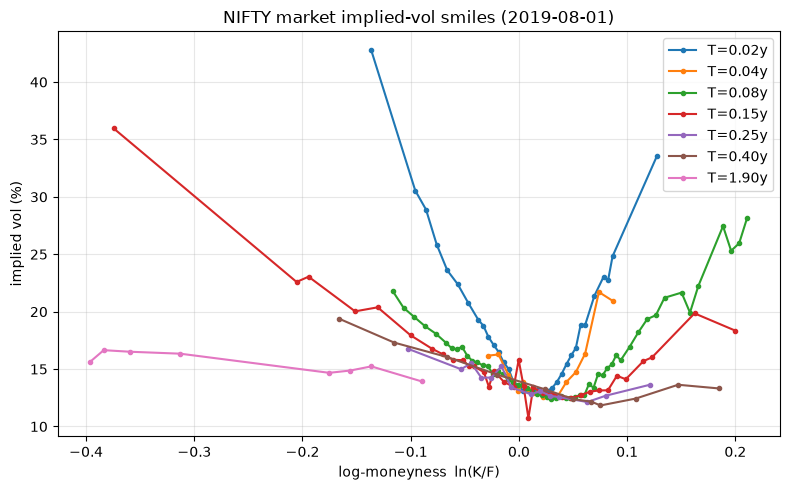

In [7]:
fig, ax = plt.subplots(figsize=(8, 5))
for T in sorted(surface.TTM.unique()):
    s = surface[surface.TTM == T].sort_values("logm")
    ax.plot(s.logm, s.iv * 100, marker="o", ms=3, label=f"T={T:.2f}y")
ax.set_xlabel("log-moneyness  ln(K/F)"); ax.set_ylabel("implied vol (%)")
ax.set_title(f"NIFTY market implied-vol smiles ({TRADE_DATE.date()})")
ax.grid(alpha=0.3); ax.legend()
plt.tight_layout(); plt.show()

In [12]:
## 5. Gridded IV surface (well-covered region only)
# Fixes: drop the lone far-dated expiry (1.90y, 8 strikes, put-wing only) that distorts the
# maturity axis; restrict to a moneyness band the liquid expiries actually share; interpolate
# each smile only within its own support (no invented data).
from scipy.interpolate import interp1d

work = surface[surface.TTM <= 0.45].copy()             # drop the sparse 1.90y slice
logm_grid = np.linspace(-0.12, 0.12, 25)               # band the short expiries share
mats = np.array(sorted(work.TTM.unique()))

iv_grid = np.full((len(mats), len(logm_grid)), np.nan)
for i, T in enumerate(mats):
    s = work[work.TTM == T].sort_values("logm")
    if len(s) < 4:
        continue
    lo, hi = s.logm.min(), s.logm.max()                # only within this expiry's traded range
    f = interp1d(s.logm.values, s.iv.values, kind="linear", bounds_error=False)
    band = (logm_grid >= lo) & (logm_grid <= hi)
    iv_grid[i, band] = f(logm_grid[band])

coverage = np.isfinite(iv_grid).mean()
print(f"maturities kept: {mats} | grid coverage: {coverage:.0%}")

maturities kept: [0.019 0.036 0.077 0.153 0.249 0.403] | grid coverage: 89%


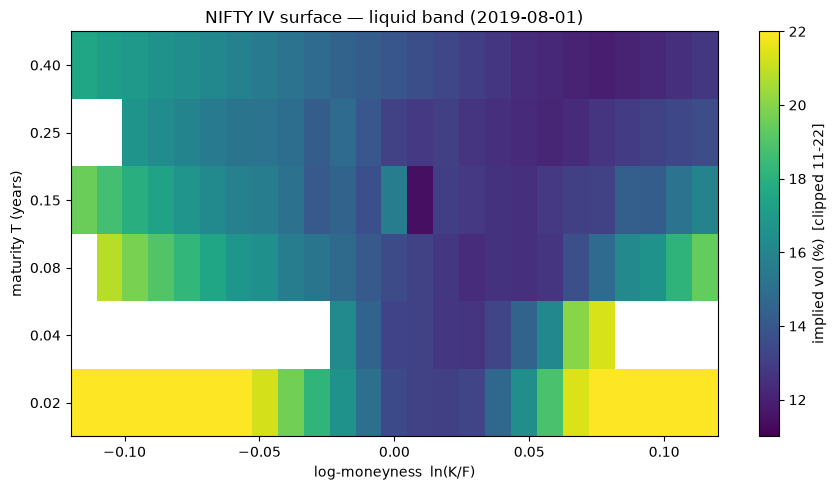

In [13]:
# Heatmap with a clipped color scale (so short-wing spikes don't wash out the mid-surface),
# and an evenly-spaced maturity axis via row index (labels show the real T values).
fig, ax = plt.subplots(figsize=(9, 5))
im = ax.imshow(iv_grid * 100, origin="lower", aspect="auto", cmap="viridis",
               vmin=11, vmax=22,                        # clip: the bulk of the surface
               extent=[logm_grid[0], logm_grid[-1], 0, len(mats)])
ax.set_yticks(np.arange(len(mats)) + 0.5); ax.set_yticklabels([f"{t:.2f}" for t in mats])
fig.colorbar(im, ax=ax, label="implied vol (%)  [clipped 11-22]")
ax.set_xlabel("log-moneyness  ln(K/F)"); ax.set_ylabel("maturity T (years)")
ax.set_title(f"NIFTY IV surface — liquid band ({TRADE_DATE.date()})")
plt.tight_layout(); plt.show()

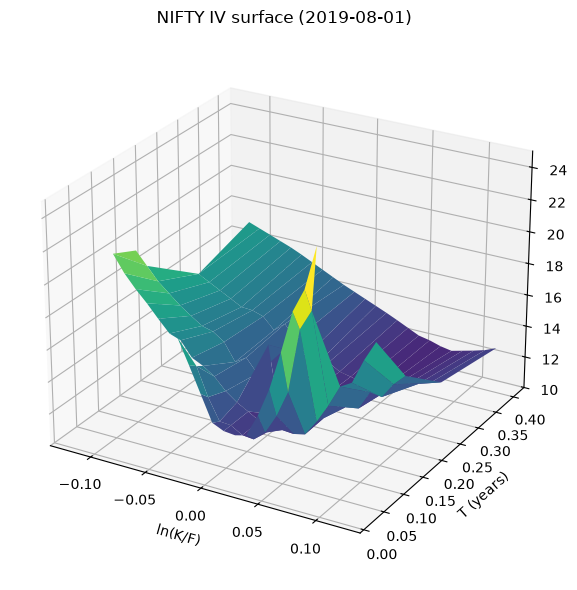

In [17]:
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

X, Y = np.meshgrid(logm_grid, mats)
Z = np.ma.masked_invalid(iv_grid * 100)          # mask gaps so they don't render as spikes
fig = plt.figure(figsize=(9, 6)); ax = fig.add_subplot(111, projection="3d")
ax.plot_surface(X, Y, Z, cmap="viridis", vmin=11, vmax=22, edgecolor="none")
ax.set_xlabel("ln(K/F)"); ax.set_ylabel("T (years)"); ax.set_zlabel("IV (%)")
ax.set_zlim(10, 25)                               # crop the wing spikes so the body is visible
ax.set_title(f"NIFTY IV surface ({TRADE_DATE.date()})")
ax.view_init(elev=25, azim=-60)
plt.tight_layout(); plt.show()

## 6. Numerical Heston: full-truncation Euler simulator

The core "numerical Heston" piece. We simulate the risk-neutral dynamics in log-price form
$$dX = (r - \tfrac12 v)\,dt + \sqrt{v}\,dW^S,\qquad dv = \kappa(\theta - v)\,dt + \xi\sqrt{v}\,dW^v,\qquad dW^S dW^v = \rho\,dt,$$
with the **full-truncation** fix (Lord et al. 2010): wherever $v$ appears under a square root or in the
drift, use $v^+=\max(v,0)$. This keeps the variance from going imaginary when a Euler step overshoots
below zero — the standard robust scheme, and the one that tolerates a violated Feller condition.

Paths share one fine time grid; we snapshot the terminal price at each requested maturity so the whole
term structure comes from a single consistent simulation.

In [18]:
def simulate_heston_terminals(S0, v0, kappa, theta, xi, rho, r, maturities,
                              steps_per_year=252, n_paths=100_000, seed=0):
    """Full-truncation Euler MC. Returns {maturity: array of terminal prices S_T}."""
    rng = np.random.default_rng(seed)
    mats = np.sort(np.asarray(maturities, dtype=float))
    Tmax = mats[-1]
    n_steps = int(np.ceil(Tmax * steps_per_year))
    dt = Tmax / n_steps
    sqrt_dt = np.sqrt(dt)
    # Map each maturity to the nearest step index for snapshotting.
    snap = {int(np.clip(round(T / dt), 1, n_steps)): T for T in mats}

    X = np.full(n_paths, np.log(S0))          # log-price
    v = np.full(n_paths, float(v0))           # variance
    out = {}
    for step in range(1, n_steps + 1):
        z1 = rng.standard_normal(n_paths)                       # drives variance
        z2 = rng.standard_normal(n_paths)
        zS = rho * z1 + np.sqrt(1.0 - rho * rho) * z2           # correlated price shock
        vp = np.maximum(v, 0.0)                                 # full truncation
        v = v + kappa * (theta - vp) * dt + xi * np.sqrt(vp) * sqrt_dt * z1
        X = X + (r - 0.5 * vp) * dt + np.sqrt(vp) * sqrt_dt * zS
        if step in snap:
            out[snap[step]] = np.exp(X).copy()
    return out

In [19]:
# Initial (un-calibrated) NIFTY-like parameters -- calibration is the next section.
heston_params = dict(S0=11100.0, v0=0.018, kappa=1.5, theta=0.020, xi=0.5, rho=-0.7, r=R)

# Validation: Feller flag, martingale E[S]/F ~= 1, and a sane ATM level / skew sign.
_mats = sorted(surface[surface.TTM <= 0.45].TTM.unique())
_term = simulate_heston_terminals(maturities=_mats, n_paths=200_000, seed=1,
                                  **{k: heston_params[k] for k in
                                     ["S0","v0","kappa","theta","xi","rho","r"]})
feller = 2*heston_params["kappa"]*heston_params["theta"] >= heston_params["xi"]**2
print(f"Feller 2*k*theta >= xi^2: {feller}  (violation is acceptable under full truncation)")
for T in _mats:
    ST = _term[T]; F = heston_params["S0"]*np.exp(heston_params["r"]*T)
    print(f"  T={T:.3f} | E[S]/F={ST.mean()/F:.4f} (martingale check)")

Feller 2*k*theta >= xi^2: False  (violation is acceptable under full truncation)
  T=0.019 | E[S]/F=1.0000 (martingale check)
  T=0.036 | E[S]/F=1.0000 (martingale check)
  T=0.077 | E[S]/F=0.9999 (martingale check)
  T=0.153 | E[S]/F=1.0000 (martingale check)
  T=0.249 | E[S]/F=1.0001 (martingale check)
  T=0.403 | E[S]/F=1.0000 (martingale check)


## 7. Model IV surface vs the market

Price the same log-moneyness grid off the simulated terminals (OTM side, discounted MC payoff), invert
Black-76 to get the **model** IV surface, and overlay it on the market smiles. With un-calibrated
parameters we expect the right *shape* (downward skew, ~13% ATM) but not a tight fit yet — that's what
calibration fixes next.

In [20]:
def heston_model_surface(params, maturities, logm_grid, n_paths=200_000, seed=1):
    """Price the (logm, T) grid under Heston and invert to a model IV table."""
    term = simulate_heston_terminals(
        maturities=maturities, n_paths=n_paths, seed=seed,
        **{k: params[k] for k in ["S0","v0","kappa","theta","xi","rho","r"]})
    S0, r = params["S0"], params["r"]
    rows = []
    for T in maturities:
        ST = term[T]; F = S0*np.exp(r*T); D = np.exp(-r*T)
        for lm in logm_grid:
            K = F*np.exp(lm)
            if K >= F:                                   # OTM call
                price, cp = D*np.mean(np.maximum(ST-K, 0.0)), "C"
            else:                                        # OTM put
                price, cp = D*np.mean(np.maximum(K-ST, 0.0)), "P"
            v = implied_vol(price, F, K, T, r, cp)
            if np.isfinite(v):
                rows.append(dict(TTM=round(T,3), logm=lm, iv=v))
    return pd.DataFrame(rows)

logm_grid = np.linspace(-0.12, 0.12, 25)
model_surface = heston_model_surface(heston_params, _mats, logm_grid)
print("model surface points:", len(model_surface))

model surface points: 139


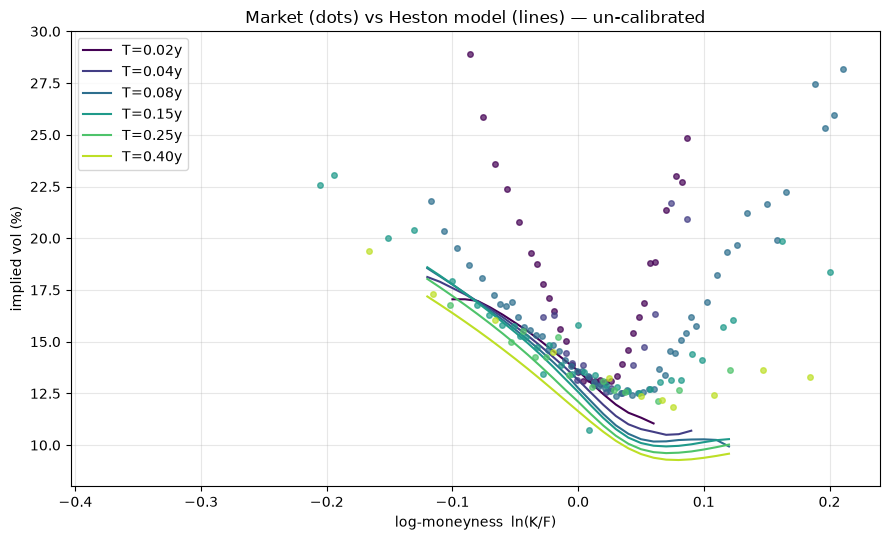

In [21]:
# Overlay: market (dots) vs Heston model (lines), one colour per maturity.
fig, ax = plt.subplots(figsize=(9, 5.5))
colors = plt.cm.viridis(np.linspace(0, 0.9, len(_mats)))
for c, T in zip(colors, _mats):
    m = surface[surface.TTM == T].sort_values("logm")
    mo = model_surface[model_surface.TTM == round(T,3)].sort_values("logm")
    ax.plot(m.logm, m.iv*100, "o", ms=4, color=c, alpha=0.7)
    ax.plot(mo.logm, mo.iv*100, "-", color=c, label=f"T={T:.2f}y")
ax.set_xlabel("log-moneyness  ln(K/F)"); ax.set_ylabel("implied vol (%)")
ax.set_title("Market (dots) vs Heston model (lines) — un-calibrated")
ax.grid(alpha=0.3); ax.legend(); ax.set_ylim(8, 30)
plt.tight_layout(); plt.show()

## Next steps

**Now — Calibrate.** Fit $(\kappa, \theta, \xi, \rho, v_0)$ so the model surface matches the market.
- Objective: squared IV error (model − market), weighted toward the liquid ATM region.
- Expect $\xi$ to rise (the un-calibrated model lacks wing curvature) and a mid-maturity compromise
  (one parameter set can't match the steep short smiles and flat long smiles at once — a known Heston limit).
- Use fixed common random numbers across objective evaluations (smooth objective), then re-simulate at
  high path count at the optimum.

**Then — Generate the dataset.** Sample $(\kappa, \theta, \xi, \rho, v_0)$ around the calibrated values
→ price each draw → one clean, gap-free IV surface per draw, all on the same fixed (moneyness, $T$) grid.
This stack of surfaces is the flow-matching target.

**Finally — Flow matching.** Reuse the Phase-1/2 pipeline (FM-OT / FM-Diff / SM-Diff) on the surface
dataset, adapting only the data sampler and the metrics to the surface grid.